# 📰 Fake News Detection Using Machine Learning

## Project Overview

Fake news has become a major challenge in today's digital world. This project aims to classify news articles as **Fake** or **Real** using Machine Learning and Natural Language Processing (NLP).

---

## Objectives

- Load and merge Fake & Real News datasets
- Perform Exploratory Data Analysis (EDA)
- Clean and preprocess text data
- Convert text into numerical features using TF-IDF
- Train multiple Machine Learning models
- Compare model performance
- Save the best model
- Deploy the model using Streamlit

---

## Dataset

- Fake.csv
- True.csv

Source:
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

---

## Algorithms Used

- Logistic Regression
- Multinomial Naive Bayes
- Passive Aggressive Classifier
- Decision Tree
- Random Forest
- Linear SVM

---

## Libraries

- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- WordCloud
- Scikit-Learn
- Joblib

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

plt.style.use("ggplot")

print("All Libraries Imported Successfully.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KUSHAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KUSHAL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\KUSHAL\AppData\Roaming\nltk_data...


All Libraries Imported Successfully.


[nltk_data]   Package omw-1.4 is already up-to-date!


# Load Dataset

In [4]:
fake = pd.read_csv("../dataset/Fake.csv")
true = pd.read_csv("../dataset/True.csv")

In [5]:
print("Fake Shape :", fake.shape)
print("True Shape :", true.shape)

Fake Shape : (23481, 4)
True Shape : (21417, 4)


In [6]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# Add Target Labels

In [8]:
fake["label"] = 0
true["label"] = 1

# Merge Dataset

In [9]:
df = pd.concat([fake, true], axis=0)

In [10]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
print(df.shape)

(44898, 5)


In [12]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# Dataset Information

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [14]:
df.describe(include="all")

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [15]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(209)

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(44689, 5)

# Exploratory Data Analysis (EDA)

In this section, we will analyze the dataset distribution,
missing values, news categories, and text patterns.

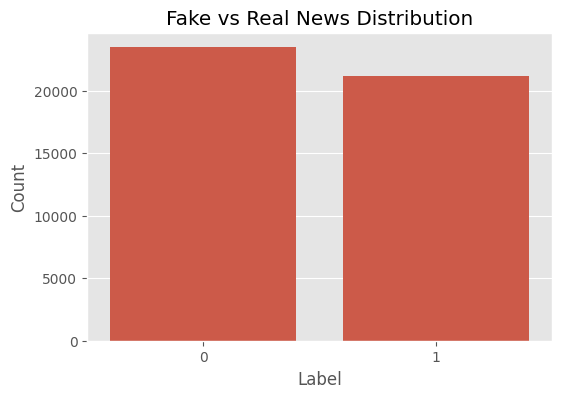

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Fake vs Real News Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [20]:
eda_df = df.copy()

eda_df["label_name"] = eda_df["label"].map(
    {
        0:"Fake",
        1:"Real"
    }
)

eda_df.head()

,title,text,subject,date,label,label_name
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Fake
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Real
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Real
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,Fake
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Real


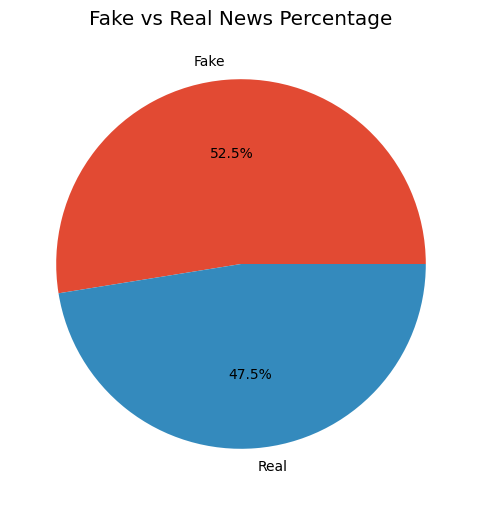

In [21]:
label_counts = eda_df["label_name"].value_counts()


plt.figure(figsize=(6,6))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct="%1.1f%%"
)

plt.title("Fake vs Real News Percentage")

plt.show()

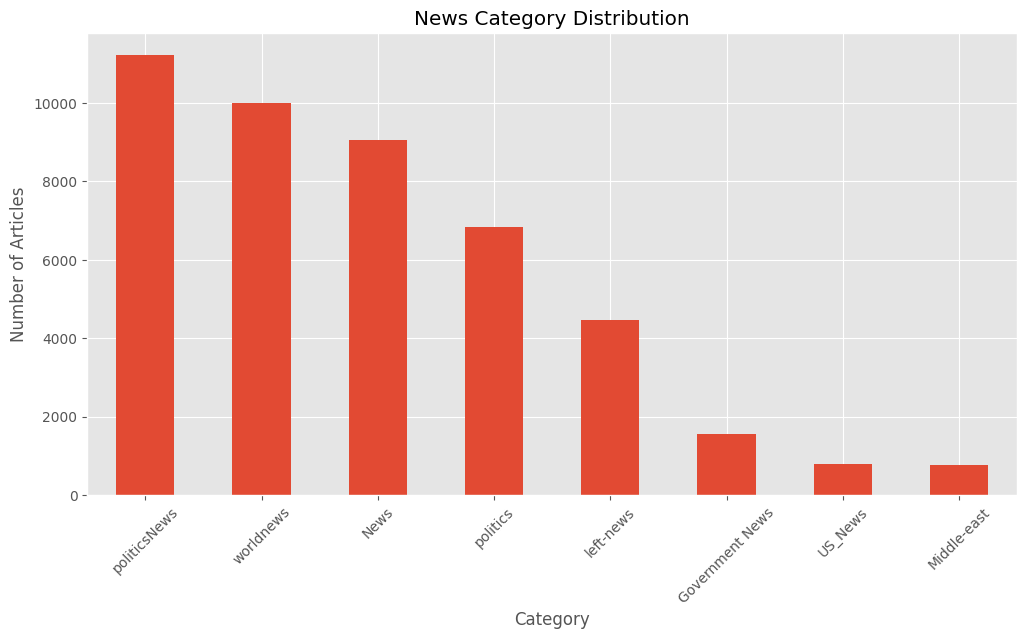

In [22]:
plt.figure(figsize=(12,6))

df["subject"].value_counts().plot(
    kind="bar"
)

plt.title(
    "News Category Distribution"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Number of Articles"
)

plt.xticks(rotation=45)

plt.show()

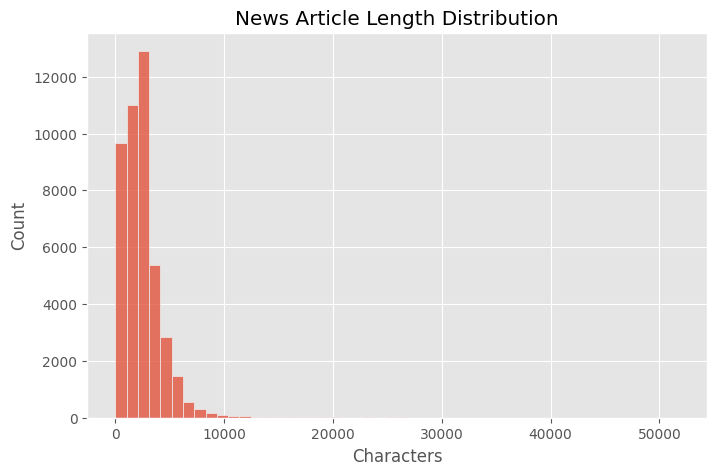

In [23]:
df["text_length"] = df["text"].apply(
    lambda x: len(str(x))
)


plt.figure(figsize=(8,5))

sns.histplot(
    df["text_length"],
    bins=50
)

plt.title(
    "News Article Length Distribution"
)

plt.xlabel(
    "Characters"
)

plt.show()

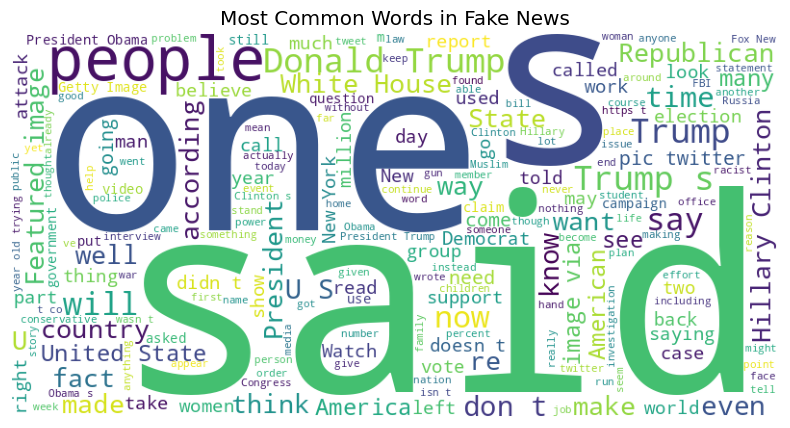

In [24]:
fake_text = " ".join(
    df[df["label"]==0]["text"]
)


fake_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)


plt.figure(figsize=(10,5))

plt.imshow(fake_wordcloud)

plt.axis("off")

plt.title(
    "Most Common Words in Fake News"
)

plt.show()

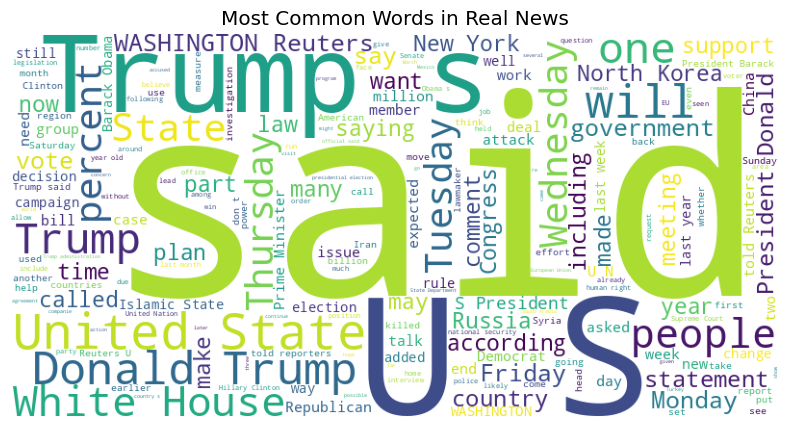

In [25]:
real_text = " ".join(
    df[df["label"]==1]["text"]
)


real_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(real_text)


plt.figure(figsize=(10,5))

plt.imshow(real_wordcloud)

plt.axis("off")

plt.title(
    "Most Common Words in Real News"
)

plt.show()

# Text Preprocessing

Machine learning models cannot understand raw text.
We will clean the text by:

- Lowercasing
- Removing URLs
- Removing punctuation
- Removing stopwords
- Lemmatization

In [26]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

In [27]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    text = re.sub(
        r"\d+",
        "",
        text
    )

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )


    words = text.split()


    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]


    return " ".join(words)

In [28]:
df["content"] = (
    df["title"]
    +" "
    +df["text"]
)


df["clean_content"] = (
    df["content"]
    .apply(clean_text)
)


df.head()

,title,text,subject,date,label,text_length,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,1028,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed ‘cou...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,4820,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,1848,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,1244,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,3137,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


# TF-IDF Feature Extraction

TF-IDF converts text data into numerical features
that machine learning algorithms can understand.

In [29]:
X = df["clean_content"]

y = df["label"]


from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)


X_train_tfidf = tfidf.fit_transform(
    X_train
)


X_test_tfidf = tfidf.transform(
    X_test
)


print(
    X_train_tfidf.shape
)

(35751, 5000)


# Model Training

We will train multiple Machine Learning algorithms and compare their performance.

Models:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Passive Aggressive Classifier
4. Decision Tree
5. Random Forest
6. Linear SVM

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

In [32]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000
    ),


    "Naive Bayes":
    MultinomialNB(),


    "Passive Aggressive":
    PassiveAggressiveClassifier(
        max_iter=1000,
        random_state=42
    ),


    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),


    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),


    "Linear SVM":
    LinearSVC()

}

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


results = []

trained_models = {}


for name, model in models.items():

    print(
        "Training:",
        name
    )


    model.fit(
        X_train_tfidf,
        y_train
    )


    prediction = model.predict(
        X_test_tfidf
    )


    accuracy = accuracy_score(
        y_test,
        prediction
    )


    precision = precision_score(
        y_test,
        prediction
    )


    recall = recall_score(
        y_test,
        prediction
    )


    f1 = f1_score(
        y_test,
        prediction
    )


    results.append(
        [
            name,
            accuracy,
            precision,
            recall,
            f1
        ]
    )


    trained_models[name] = model


print("Training Completed")

Training: Logistic Regression
Training: Naive Bayes
Training: Passive Aggressive
Training: Decision Tree
Training: Random Forest
Training: Linear SVM
Training Completed


In [34]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)


results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.997762,0.997643,0.997643,0.997643
3,Decision Tree,0.994853,0.995981,0.993164,0.994570
5,Linear SVM,0.994630,0.993877,0.994814,0.994345
2,Passive Aggressive,0.993623,0.993864,0.992692,0.993278
0,Logistic Regression,0.986574,0.982896,0.988920,0.985899
1,Naive Bayes,0.928396,0.930038,0.918199,0.924081


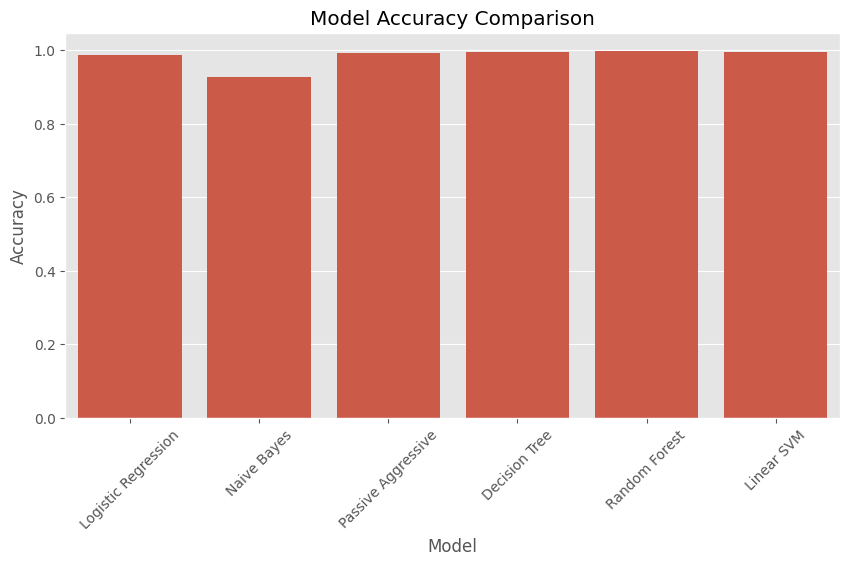

In [35]:
plt.figure(
    figsize=(10,5)
)


sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)


plt.title(
    "Model Accuracy Comparison"
)


plt.xticks(
    rotation=45
)


plt.show()

In [36]:
best_model_name = (

    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]

)


best_model = trained_models[
    best_model_name
]


print(
    "Best Model:",
    best_model_name
)

Best Model: Random Forest


In [37]:
from sklearn.metrics import classification_report


best_prediction = best_model.predict(
    X_test_tfidf
)


print(
    classification_report(
        y_test,
        best_prediction
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



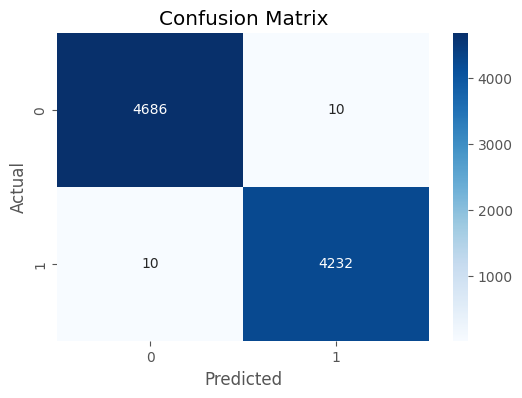

In [38]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_test,
    best_prediction
)


plt.figure(
    figsize=(6,4)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "Confusion Matrix"
)


plt.show()

# Save Trained Model

The trained model and TF-IDF vectorizer will be saved using Joblib.

These files will be used in the Streamlit application.

In [40]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [41]:
import joblib


joblib.dump(
    best_model,
    "models/fake_news_model.pkl"
)


joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)


print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [42]:
def predict_news(news):

    cleaned = clean_text(
        news
    )


    vector = tfidf.transform(
        [cleaned]
    )


    prediction = best_model.predict(
        vector
    )[0]


    if prediction == 1:

        return "Real News"

    else:

        return "Fake News"

In [43]:
sample = """
The government announced a new technology
development program after official approval.
"""


predict_news(sample)

'Fake News'

# Conclusion

In this project, we successfully built a Fake News Detection system using Machine Learning.

Steps completed:

- Data Collection
- Data Cleaning
- Exploratory Data Analysis
- Text Preprocessing
- TF-IDF Feature Extraction
- Machine Learning Model Training
- Model Evaluation
- Best Model Selection
- Model Saving

The trained model can now be deployed using Streamlit for real-time fake news detection.

## Future Scope

- Use Deep Learning models like LSTM and BERT
- Add multilingual support
- Connect with real-time news APIs
- Add Explainable AI techniques